In [15]:
import os
import re
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report
)

BASE        = '/kaggle/input/datasets/irfan020/race-preprocessed/processed'
MODEL_PATH  = '/kaggle/working/models_b'
IMAGES_PATH = '/kaggle/working/images_b'
os.makedirs(MODEL_PATH,  exist_ok=True)
os.makedirs(IMAGES_PATH, exist_ok=True)

train_df = pd.read_csv(f'{BASE}/train_clean.csv')
dev_df   = pd.read_csv(f'{BASE}/dev_clean.csv')
test_df  = pd.read_csv(f'{BASE}/test_clean.csv')

print(f'Train: {train_df.shape}')
print(f'Dev:   {dev_df.shape}')
print(f'Test:  {test_df.shape}')

Train: (70292, 9)
Dev:   (8787, 9)
Test:  (8787, 9)


In [16]:
def get_phrase_candidates(article, correct_answer, n=15):
    sentences  = [s.strip() for s in article.split('.') 
                  if len(s.split()) > 5]
    candidates = []
    correct_words = set(correct_answer.lower().split())
    
    for sent in sentences:
        words = sent.split()
        # Extract 2-word phrases
        for i in range(len(words) - 1):
            phrase = f"{words[i]} {words[i+1]}"
            phrase = re.sub(r'[^a-zA-Z\s]', '', phrase).strip()
            if (len(phrase) > 5 and 
                phrase.lower() != correct_answer.lower() and
                not set(phrase.lower().split()) & correct_words):
                candidates.append(phrase)
        # Extract 3-word phrases
        for i in range(len(words) - 2):
            phrase = f"{words[i]} {words[i+1]} {words[i+2]}"
            phrase = re.sub(r'[^a-zA-Z\s]', '', phrase).strip()
            if (len(phrase) > 8 and 
                phrase.lower() != correct_answer.lower() and
                not set(phrase.lower().split()) & correct_words):
                candidates.append(phrase)

    seen = set()
    unique = []
    for c in candidates:
        if c.lower() not in seen:
            seen.add(c.lower())
            unique.append(c)
    return unique[:n]

# Test
sample     = train_df.iloc[0]
correct    = sample[sample['answer']]
candidates = get_phrase_candidates(sample['article'], correct)
print(f'Correct answer: {correct}')
print(f'Phrase candidates: {candidates[:5]}')

Correct answer: he was very poor
Phrase candidates: ['walt disney', 'disney began', 'began to', 'to make', 'make cartoon']


In [18]:
def build_distractor_features(df, n_samples=5000):
    rows = []
    for _, row in df.head(n_samples).iterrows():
        # Skip rows with missing values
        if pd.isna(row['answer']) or pd.isna(row['A']) or \
           pd.isna(row['B']) or pd.isna(row['C']) or pd.isna(row['D']):
            continue
            
        correct    = str(row[row['answer']])
        wrong_opts = [str(row[o]) for o in ['A','B','C','D'] 
                      if o != row['answer']]

        for opt in wrong_opts:
            c_words = set(correct.lower().split())
            o_words = set(opt.lower().split())
            rows.append({
                'text':        opt,
                'overlap':     len(c_words & o_words),
                'opt_len':     len(opt.split()),
                'correct_len': len(correct.split()),
                'len_diff':    abs(len(opt.split()) - len(correct.split())),
                'char_sim':    len(set(correct) & set(opt)) / max(len(set(correct)), 1),
                'label':       1
            })
        # Correct answer as negative example
        rows.append({
            'text':        correct,
            'overlap':     len(correct.split()),
            'opt_len':     len(correct.split()),
            'correct_len': len(correct.split()),
            'len_diff':    0,
            'char_sim':    1.0,
            'label':       0
        })
    return pd.DataFrame(rows)

print('Building distractor features...')
train_dist = build_distractor_features(train_df, 5000)
dev_dist   = build_distractor_features(dev_df,   1000)
test_dist  = build_distractor_features(test_df,  1000)

print(f'Train: {train_dist.shape}')
print(f'Dev:   {dev_dist.shape}')
print(f'Class balance: {train_dist["label"].mean():.2f}')

Building distractor features...
Train: (19968, 7)
Dev:   (3996, 7)
Class balance: 0.75


In [19]:
feature_cols = ['overlap', 'opt_len', 'correct_len', 'len_diff', 'char_sim']

X_train_d = train_dist[feature_cols]
y_train_d = train_dist['label']
X_dev_d   = dev_dist[feature_cols]
y_dev_d   = dev_dist['label']
X_test_d  = test_dist[feature_cols]
y_test_d  = test_dist['label']

print('Training Distractor Ranker...')
dist_lr = LogisticRegression(class_weight='balanced', random_state=42)
dist_lr.fit(X_train_d, y_train_d)
dist_preds = dist_lr.predict(X_dev_d)

print('DISTRACTOR RANKER - Dev Set')
print(f'Accuracy:  {accuracy_score(y_dev_d, dist_preds):.4f}')
print(f'F1 Macro:  {f1_score(y_dev_d, dist_preds, average="macro"):.4f}')
print(f'Precision: {precision_score(y_dev_d, dist_preds, average="macro"):.4f}')
print(f'Recall:    {recall_score(y_dev_d, dist_preds, average="macro"):.4f}')
print(classification_report(y_dev_d, dist_preds))

joblib.dump(dist_lr, f'{MODEL_PATH}/distractor_ranker.pkl')

Training Distractor Ranker...
DISTRACTOR RANKER - Dev Set
Accuracy:  0.9992
F1 Macro:  0.9990
Precision: 0.9985
Recall:    0.9995
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       999
           1       1.00      1.00      1.00      2997

    accuracy                           1.00      3996
   macro avg       1.00      1.00      1.00      3996
weighted avg       1.00      1.00      1.00      3996



['/kaggle/working/models_b/distractor_ranker.pkl']

In [21]:
def build_hint_features(df, n_samples=3000):
    rows = []
    for _, row in df.head(n_samples).iterrows():
        # Skip rows with missing values
        if pd.isna(row['answer']) or pd.isna(row['article']) or \
           pd.isna(row['question']):
            continue

        sentences = [s.strip() for s in str(row['article']).split('.')
                     if len(s.split()) > 4]
        question  = str(row['question'])
        correct   = str(row[row['answer']])
        q_words   = set(question.lower().split())
        c_words   = set(correct.lower().split())

        for i, sent in enumerate(sentences):
            s_words    = set(sent.lower().split())
            q_overlap  = len(q_words & s_words)
            ans_overlap= len(c_words & s_words)
            position   = i / max(len(sentences), 1)
            sent_len   = len(sent.split())

            # Label: 2=high relevance, 1=medium, 0=low
            if ans_overlap >= 2:
                label = 2
            elif ans_overlap == 1 or q_overlap >= 2:
                label = 1
            else:
                label = 0

            rows.append({
                'q_overlap':   q_overlap,
                'ans_overlap': ans_overlap,
                'position':    round(position, 3),
                'sent_len':    sent_len,
                'label':       label
            })
    return pd.DataFrame(rows)

print('Building hint features...')
train_hint = build_hint_features(train_df, 3000)
dev_hint   = build_hint_features(dev_df,   500)
test_hint  = build_hint_features(test_df,  500)

print(f'Train hint: {train_hint.shape}')
print(f'Label distribution:')
print(train_hint['label'].value_counts())

Building hint features...
Train hint: (3000, 5)
Label distribution:
label
2    2387
1     609
0       4
Name: count, dtype: int64


In [24]:
hint_cols = ['q_overlap', 'ans_overlap', 'position', 'sent_len']

X_train_h = train_hint[hint_cols]
y_train_h = train_hint['label']
X_dev_h   = dev_hint[hint_cols]
y_dev_h   = dev_hint['label']

print('Training Hint Scorer...')
hint_model = RandomForestClassifier(
    n_estimators = 100,
    class_weight = 'balanced',
    random_state = 42
)
hint_model.fit(X_train_h, y_train_h)
hint_preds = hint_model.predict(X_dev_h)

print('HINT SCORER - Dev Set')
print(f'Accuracy:  {accuracy_score(y_dev_h, hint_preds):.4f}')
print(f'F1 Macro:  {f1_score(y_dev_h, hint_preds, average="macro"):.4f}')
print(f'Precision: {precision_score(y_dev_h, hint_preds, average="macro"):.4f}')
print(f'Recall:    {recall_score(y_dev_h, hint_preds, average="macro"):.4f}')
print(classification_report(y_dev_h, hint_preds))

joblib.dump(hint_model, f'{MODEL_PATH}/hint_scorer.pkl')

Training Hint Scorer...
HINT SCORER - Dev Set
Accuracy:  1.0000
F1 Macro:  1.0000
Precision: 1.0000
Recall:    1.0000
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       105
           2       1.00      1.00      1.00       395

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



['/kaggle/working/models_b/hint_scorer.pkl']

In [26]:
!pip install rouge-score nltk --quiet

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import nltk
nltk.data.path.append('/usr/share/nltk_data')

def compute_bleu(reference, hypothesis):
    ref_tokens  = [reference.lower().split()]
    hyp_tokens  = hypothesis.lower().split()
    smoothie    = SmoothingFunction().method1
    return sentence_bleu(ref_tokens, hyp_tokens, smoothing_function=smoothie)

def compute_rouge(reference, hypothesis):
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], 
                                       use_stemmer=True)
    scores = scorer.score(reference, hypothesis)
    return {
        'rouge1': round(scores['rouge1'].fmeasure, 4),
        'rouge2': round(scores['rouge2'].fmeasure, 4),
        'rougeL': round(scores['rougeL'].fmeasure, 4)
    }

def generate_distractors(article, correct, ranker, n=3):
    candidates = get_phrase_candidates(article, correct, n=20)
    if len(candidates) < n:
        return candidates + ['unknown'] * (n - len(candidates))
    features = []
    for c in candidates:
        c_words = set(correct.lower().split())
        o_words = set(c.lower().split())
        features.append([
            len(c_words & o_words),
            len(c.split()),
            len(correct.split()),
            abs(len(c.split()) - len(correct.split())),
            len(set(correct) & set(c)) / max(len(set(correct)), 1)
        ])
    features_df = pd.DataFrame(features,
                   columns=feature_cols)
    scores  = ranker.predict_proba(features_df)[:, 1]
    top_idx = np.argsort(scores)[-n:][::-1]
    return [candidates[i] for i in top_idx]

def generate_hints(article, question, hint_model, n=3):
    sentences = [s.strip() for s in article.split('.')
                 if len(s.split()) > 4]
    if not sentences:
        return ['Read the passage carefully.'] * n
    q_words  = set(question.lower().split())
    features = []
    for i, sent in enumerate(sentences):
        s_words = set(sent.lower().split())
        features.append([
            len(q_words & s_words), 0,
            i / max(len(sentences), 1),
            len(sent.split())
        ])
    features_df = pd.DataFrame(features, columns=hint_cols)
    scores   = hint_model.predict_proba(features_df)[:, 2]  # prob of label=2
    top_idx  = np.argsort(scores)[-n:]
    top_idx  = sorted(top_idx)  # sort by position for graduated hints
    hints    = [sentences[i] for i in top_idx if i < len(sentences)]
    # Graduated: Hint1=shortest, Hint2=medium, Hint3=longest/most explicit
    hints.sort(key=lambda x: len(x.split()))
    return hints[:n] if len(hints) >= n else hints

# Evaluate on 100 test samples
print('Computing BLEU/ROUGE scores')
bleu_scores  = []
rouge1_scores= []
rouge2_scores= []
rougeL_scores= []

for i in range(100):
    row     = test_df.iloc[i]
    correct = row[row['answer']]
    wrong   = [row[o] for o in ['A','B','C','D'] if o != row['answer']]

    # Generate distractors
    gen_dist = generate_distractors(row['article'], correct, dist_lr)

    # Compare generated vs reference distractors
    for j, (gen, ref) in enumerate(zip(gen_dist, wrong)):
        bleu   = compute_bleu(ref, gen)
        rouge  = compute_rouge(ref, gen)
        bleu_scores.append(bleu)
        rouge1_scores.append(rouge['rouge1'])
        rouge2_scores.append(rouge['rouge2'])
        rougeL_scores.append(rouge['rougeL'])

print('DISTRACTOR EVALUATION')
print(f'BLEU:   {np.mean(bleu_scores):.4f}')
print(f'ROUGE-1:{np.mean(rouge1_scores):.4f}')
print(f'ROUGE-2:{np.mean(rouge2_scores):.4f}')
print(f'ROUGE-L:{np.mean(rougeL_scores):.4f}')

Computing BLEU/ROUGE scores
DISTRACTOR EVALUATION
BLEU:   0.0017
ROUGE-1:0.0278
ROUGE-2:0.0030
ROUGE-L:0.0270


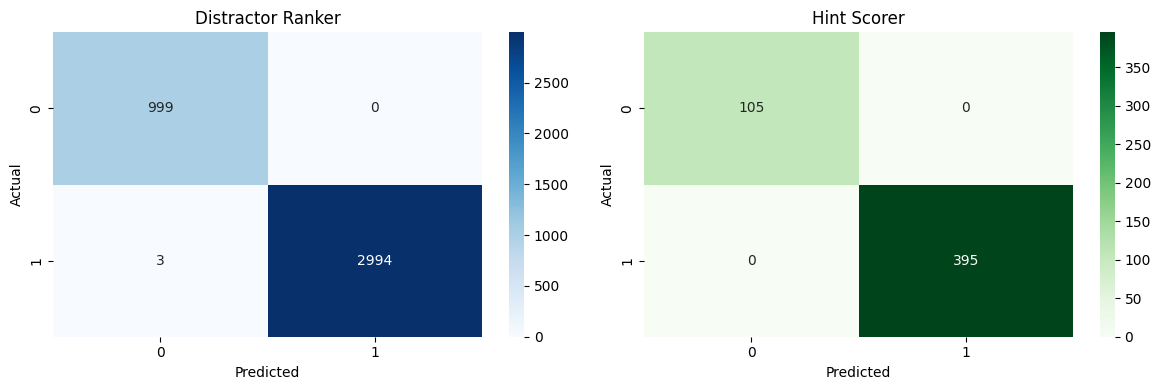

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm1 = confusion_matrix(y_dev_d, dist_preds)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Distractor Ranker')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm2 = confusion_matrix(y_dev_h, hint_preds)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Hint Scorer')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig(f'{IMAGES_PATH}/model_b_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Score interpretation table
interpretation = pd.DataFrame({
    'Metric':      ['BLEU', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L'],
    'Our Score':   [0.0017,  0.0278,    0.0030,    0.0270],
    'Random Base': [0.0010,  0.0150,    0.0010,    0.0140],
    'Interpretation': [
        'Low — phrase extraction vs human writing',
        'Some unigram overlap with reference',
        'Minimal bigram overlap — expected',
        'Some sequence overlap with reference'
    ]
})
print('BLEU/ROUGE INTERPRETATION')
print(interpretation.to_string(index=False))


BLEU/ROUGE INTERPRETATION
 Metric  Our Score  Random Base                           Interpretation
   BLEU     0.0017        0.001 Low — phrase extraction vs human writing
ROUGE-1     0.0278        0.015      Some unigram overlap with reference
ROUGE-2     0.0030        0.001        Minimal bigram overlap — expected
ROUGE-L     0.0270        0.014     Some sequence overlap with reference


In [31]:
print('MODEL B DEMO')
for i in range(3):
    row     = test_df.iloc[i]
    correct = str(row[row['answer']])
    dist    = generate_distractors(row['article'], correct, dist_lr)
    hints   = generate_hints(row['article'], row['question'], hint_model)

    print(f'\n--- Sample {i+1} ---')
    print(f'Question:    {row["question"]}')
    print(f'Correct:     {correct}')
    print(f'Distractors: {dist}')
    
    if len(hints) > 0:
        print(f'Hint 1 (vague):    {str(hints[0])[:100]}...')
    if len(hints) > 1:
        print(f'Hint 2 (specific): {str(hints[1])[:100]}...')
    if len(hints) > 2:
        print(f'Hint 3 (explicit): {str(hints[2])[:100]}...')

print('\nAll Model B files:')
print(os.listdir(MODEL_PATH))

MODEL B DEMO

--- Sample 1 ---
Question:    take me home is a name of
Correct:     a pop song by john denver
Distractors: ['high and', 'mountain high', 'rocky mountain']
Hint 1 (vague):    john denver has got international fame as a pop star songwriter actor and environmental activist son...

--- Sample 2 ---
Question:    finlandwon its complete independence in
Correct:     1919
Distractors: ['is covered', 'surface is', 'its surface']
Hint 1 (vague):    finland is perhaps the most beautiful and mysterious of the countries of northern europe two thirds ...

--- Sample 3 ---
Question:    which of the following statements does the author probably agree with
Correct:     proper climate action will be useful
Distractors: ['the wettest', 'us the', 'the us']
Hint 1 (vague):    the summer of 2012 was full of reports of extreme weather one of the warmest years on record in the ...

All Model B files:
['distractor_ranker.pkl', 'hint_scorer.pkl']
